<a href="https://colab.research.google.com/github/Maneesh290318/Machine-Learning-Algorithms/blob/main/02-decision-tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# Welcome to Our Loan Approval Prediction Project!

## What is this project all about?

Imagine you're a bank trying to decide if you should approve someone's loan application. You get lots of information like their income, how much loan they want, and their credit score. This project builds a smart system (what we call a 'model') that helps you make that decision faster and more consistently.

**The main goal (purpose) of this project is to create an automated helper that can predict whether a loan application is likely to be 'Approved' or 'Not Approved' based on the applicant's details.** This helps banks make fair and quick decisions, reducing risks and speeding up the process for customers.

## What kind of 'smart system' are we building?

This system falls under something called **'Supervised Learning'**.

Think of it like teaching a child:

*   **Supervised Learning** is like showing a child many examples of 'approved' and 'not approved' loan applications, and for each one, telling them the correct answer. The child (our model) then learns the patterns and rules that lead to an 'Approved' or 'Not Approved' decision. After seeing enough examples, the child can then look at a *new* application and make a good guess about its status.

    We're giving the model 'supervision' by providing it with both the input data (income, loan amount, credit score) AND the correct output (loan status).

*   **(In contrast, Unsupervised Learning** would be like giving the child loan applications but *without* telling them which were approved or not, and asking them to find interesting groups or patterns on their own. That's not what we're doing here.)

### Our Specific Model: A Decision Tree

The specific type of model we're using is called a **'Decision Tree'**. You can think of it like a flowchart or a 'choose your own adventure' book for loan applications:

*   It starts with a question (e.g., 'Is their income above a certain amount?').
*   Based on the answer (yes or no), it moves to another question.
*   This continues until it reaches a final decision: 'Approve' or 'Not Approve'.

It's very transparent, meaning you can actually *see* and understand the rules it uses to make its predictions. This helps us trust the decisions it makes.
```

In [ ]:
import tensorflow as tf
from sklearn.tree import (
    DecisionTreeClassifier, plot_tree)
from sklearn.model_selection import (
    train_test_split)
from sklearn.metrics import (
    classification_report, accuracy_score)
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Re-import seaborn for plotting feature importances

print(f"TensorFlow: {tf.__version__}")
print("All libraries imported!")

TensorFlow: 2.20.0
All libraries imported!


This cell sets up our project by importing all the necessary tools (libraries). Think of these as specialized toolkits for handling data, building models, and showing results. We're getting ready to analyze loan data and build a decision-making system.

Here, we get our data. You can either upload your own loan application Excel file, or the system will create some example data for us to work with. The goal is to have a table with information like income, loan amount, credit score, and whether the loan was approved.

In [ ]:
# --- USER ACTION REQUIRED: UPLOAD YOUR EXCEL FILE AND UPDATE THE FILENAME BELOW ---
# For example, if you uploaded 'my_loan_data.xlsx', change 'your_loan_data.xlsx' to 'my_loan_data.xlsx'.
# Please ensure your Excel file contains the columns: 'person_income', 'loan_amnt', 'credit_score', 'loan_status'.

try:
    # Load data from your Excel file
    df = pd.read_excel('your_loan_data.xlsx') # <--- UPDATE THIS FILENAME TO YOUR UPLOADED EXCEL FILE
    print(f"Data loaded from 'your_loan_data.xlsx' with {len(df)} samples.")
    display(df.head())
except FileNotFoundError:
    print("Error: 'your_loan_data.xlsx' not found. Please upload your Excel file and update the filename in the code.")
    print("As a fallback, generating synthetic data for now to allow the notebook to run.")

    # Fallback: Generating synthetic data if the user's file is not found
    n_samples = 45000
    person_income = np.random.normal(loc=60000, scale=20000, size=n_samples).astype(int)
    person_income[person_income < 0] = 0
    loan_amnt = np.random.normal(loc=15000, scale=5000, size=n_samples).astype(int)
    loan_amnt[loan_amnt < 1000] = 1000
    credit_score = np.random.normal(loc=700, scale=80, size=n_samples).astype(int)
    credit_score[credit_score < 300] = 300
    credit_score[credit_score > 850] = 850
    loan_status = (
        (person_income > 50000).astype(int) +
        (loan_amnt < 20000).astype(int) +
        (credit_score > 650).astype(int)
    )
    loan_status = (loan_status >= 2).astype(int)
    df = pd.DataFrame({
        'person_income': person_income,
        'loan_amnt': loan_amnt,
        'credit_score': credit_score,
        'loan_status': loan_status
    })
    # We don't save to 'loan_data.csv' here if user wants to upload,
    # as the next cell directly uses `df`.
    print(f"Synthetic data created with {len(df)} samples.")
    display(df.head())

Error: 'your_loan_data.xlsx' not found. Please upload your Excel file and update the filename in the code.
As a fallback, generating synthetic data for now to allow the notebook to run.
Synthetic data created with 45000 samples.


,person_income,loan_amnt,credit_score,loan_status
0,75257,15087,713,1
1,43015,12446,761,1
2,68916,17174,675,1
3,76056,2408,702,1
4,74975,16727,607,1


This code handles loading the data. It first tries to find your specific Excel file. If it can't find it (which is common if you haven't uploaded one yet!), it automatically creates a dataset of example loan applications. This ensures we always have data to work with. We then show the first few rows of this data to get a quick overview.

### 2. Preparing Our Data

Before building a model, we need to organize and clean our data. This involves identifying the key information we'll use for decisions and getting it ready for analysis.

In [ ]:
# Define features (X) and target (y)
feature_names = ['person_income', 'loan_amnt', 'credit_score']
X = df[feature_names]
y = df['loan_status']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (45000, 3)
Target (y) shape: (45000,)


In this step, we tell our system which columns from our data are the 'inputs' (what we know about an applicant) and which column is the 'output' (what we want to predict: loan approval).

*   **Inputs (Features)**: `person_income`, `loan_amnt`, `credit_score` – these are the factors our model will use to make a decision.
*   **Output (Target)**: `loan_status` – this is the decision we want our model to predict (Approved or Not Approved).

In [ ]:
# Check the distribution of the target variable
counts = y.value_counts()
total_samples = len(y)

p0 = counts[0] / total_samples # Proportion of 'not approved'
p1 = counts[1] / total_samples # Proportion of 'approved'

print(f"Class 0 (Loan Not Approved): {counts[0]} samples ({p0:.2%})")
print(f"Class 1 (Loan Approved): {counts[1]} samples ({p1:.2%})")

# Calculate initial Gini impurity for the target variable
# Gini Impurity = 1 - (p0^2 + p1^2)
initial_gini = 1 - (p0**2 + p1**2)
print(f"Initial Gini Impurity of the target variable: {initial_gini:.4f}")

Class 0 (Loan Not Approved): 6639 samples (14.75%)
Class 1 (Loan Approved): 38361 samples (85.25%)
Initial Gini Impurity of the target variable: 0.2515


It's important to understand our 'Loan Status' data. We check how many loans were approved versus not approved. This tells us if one outcome is much more common than the other. This helps us later understand if our model is good at predicting rare outcomes.

We also look at something called 'Gini Impurity,' which is a way for the model to measure how mixed the approval outcomes are before it starts making decisions. The model's goal is to reduce this 'mixing' with each decision it makes.

The initial Gini impurity simply tells us how 'mixed' our loan approval decisions are in the overall data. A higher number means more mixed outcomes, and the model will try to reduce this impurity to make clear decisions.

In [ ]:
# Scale numerical features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled using MinMaxScaler.")
display(pd.DataFrame(X_scaled, columns=feature_names).head())

Features scaled using MinMaxScaler.


,person_income,loan_amnt,credit_score
0,0.535851,0.395736,0.741996
1,0.306279,0.321544,0.832392
2,0.490701,0.454364,0.670433
3,0.541540,0.039554,0.721281
4,0.533843,0.441807,0.542373


Imagine comparing apples and grapes – scaling makes sure everything is compared fairly. Here, we adjust our input numbers (like income and credit score) so they are all on a similar scale (between 0 and 1). This prevents factors with larger numbers (like income) from unfairly dominating the decision process, ensuring all factors are considered equally.

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (36000, 3), (36000,)
Testing set shape: (9000, 3), (9000,)


To ensure our model is truly effective for new applications, we split our data into two parts:

1.  **Training Data**: This is the data the model learns from.
2.  **Testing Data**: This is data the model has *never seen* before. We use it to evaluate how well our model performs on new, real-world scenarios.

This split helps us trust that our model isn't just memorizing old answers but can make good decisions on new ones.

### 3. Building Our Decision Tree Model

Now, we define the type of model we want to build – a Decision Tree. This model makes decisions by asking a series of yes/no questions, like a flowchart.

In [ ]:
# Initialize the Decision Tree Classifier
model = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)

print("Decision Tree Classifier initialized with max_depth=3 and Gini criterion.")

Decision Tree Classifier initialized with max_depth=3 and Gini criterion.


Here, we set up our Decision Tree model. We specify that it should not be too complex (`max_depth=3`), meaning it will only ask a few key questions. This makes the model easier to understand and less likely to make overly specific decisions that might not apply broadly.

We also tell it to use 'Gini' to measure the quality of its decision points, aiming to make each step as clear as possible.

Decision Trees don't use a 'loss function' in the traditional way that some other models do. Instead, they focus on minimizing 'impurity' at each step. This means they try to make each decision point as clear as possible, so that all loan applications going down one path are mostly approved, and those going down another are mostly not approved.

The Decision Tree learns by following a 'greedy' approach. At each step, it looks for the single best question to ask that will most effectively separate the 'approved' from 'not approved' loans. It keeps doing this, step-by-step, to build the tree. It doesn't use complex mathematical optimization like some other models; it just focuses on the best immediate decision.

### 6. Training Our Model

This is where our Decision Tree model learns how to make decisions by looking at the training data we prepared.

In [ ]:
# Train the model
model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

# Evaluate on training data
train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"Training Accuracy: {train_acc:.4f}")

# Evaluate on testing data
test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print(f"Testing Accuracy: {test_acc:.4f}")

Decision Tree model trained successfully.
Training Accuracy: 1.0000
Testing Accuracy: 1.0000


Here, our Decision Tree model analyzes the training data (`X_train`, `y_train`) to figure out the best rules for loan approval. After it 'learns', we immediately check its performance:

*   **Training Accuracy**: How well it performed on the data it just learned from. A high score here means it understood the patterns.
*   **Testing Accuracy**: How well it performed on completely new data it hasn't seen before. This is the most important measure, showing how reliable it will be in the real world.

### 7. Checking Our Model's Performance

Now we evaluate how well our Decision Tree model is actually performing. We'll look at a report, visualize its decision-making process, and see which factors it considered most important.

In [ ]:
# Classification Report
print("Classification Report for Test Data:")
print(classification_report(y_test, test_pred))

Classification Report for Test Data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1328
           1       1.00      1.00      1.00      7672

    accuracy                           1.00      9000
   macro avg       1.00      1.00      1.00      9000
weighted avg       1.00      1.00      1.00      9000



In [ ]:
# Let's explain what these terms from the classification report mean, as if you're a banker looking at loan applications!

# --- Understanding the Classification Report Terms ---

# Imagine we're trying to predict if a loan application will be 'Approved' (Class 1) or 'Not Approved' (Class 0).

# 1. Precision (When we say 'YES', how often are we right?)
#    - For 'Approved' (Class 1): If our model says an application WILL be approved, Precision tells us what percentage of those it said 'YES' to were *actually* approved.
#      High Precision means fewer false alarms. We don't want to approve loans that should have been rejected.
#    - For 'Not Approved' (Class 0): If our model says an application will *NOT* be approved, Precision tells us what percentage of those it said 'NO' to were *actually* rejected.

# 2. Recall (Out of all the 'YESes' that *should* happen, how many did we catch?)
#    - For 'Approved' (Class 1): Out of ALL the applications that *should have been* approved, Recall tells us what percentage our model correctly identified as 'Approved'.
#      High Recall means we're not missing many good applicants. We don't want to reject loans that should have been approved.
#    - For 'Not Approved' (Class 0): Out of ALL the applications that *should have been* rejected, Recall tells us what percentage our model correctly identified as 'Not Approved'.

# 3. F1-Score (A balance of Precision and Recall)
#    - This is a single score that tries to give a good overall picture by balancing Precision and Recall.
#      It's especially useful when the number of 'Approved' vs. 'Not Approved' applications is very uneven.
#      A high F1-score means the model is doing well at both being accurate in its 'YES/NO' predictions (precision) AND catching most of the real 'YES/NO' cases (recall).

# 4. Support (How many applications of each type did we test?)
#    - This simply tells you the actual number of loan applications that fell into each category (Approved or Not Approved) in the data we used for testing the model.
#      For example, 'support 1321' for Class 0 means there were 1321 actual 'Not Approved' loans in our test set.


# --- What Your Data Conveys ---

# Looking at the classification report you provided:
#               precision    recall  f1-score   support
#
#           0       1.00      1.00      1.00      1321
#           1       1.00      1.00      1.00      7679
#
#    accuracy                           1.00      9000
#   macro avg       1.00      1.00      1.00      9000
# weighted avg       1.00      1.00      1.00      9000

# This report shows incredibly high scores across the board (all 1.00 or 100%).

# - For Class 0 (Loan Not Approved):
#   - Precision of 1.00 means: When the model predicted an applicant would NOT be approved, it was always 100% correct.
#   - Recall of 1.00 means: Out of all the applicants who genuinely should NOT be approved, the model correctly identified 100% of them.
#   - F1-Score of 1.00 confirms this perfect performance for this class.
#   - Support: There were 1321 actual 'Not Approved' cases in the test data.

# - For Class 1 (Loan Approved):
#   - Precision of 1.00 means: When the model predicted an applicant WOULD be approved, it was always 100% correct.
#   - Recall of 1.00 means: Out of all the applicants who genuinely SHOULD be approved, the model correctly identified 100% of them.
#   - F1-Score of 1.00 confirms this perfect performance for this class.
#   - Support: There were 7679 actual 'Approved' cases in the test data.

# - Overall Accuracy of 1.00 means the model predicted 100% of the loan statuses correctly for the test data.

# In simple terms, this model performed perfectly on your test data.
# Every prediction it made was correct, both for approving and not approving loans.
# This is an exceptionally good result, but in real-world scenarios, such perfect scores are rare
# and might sometimes suggest the model has 'memorized' the data rather than truly learned
# general patterns (though for this synthetic dataset, it's expected).


This report gives us a detailed look at how well our model predicted loan approvals on the test data.

*   **Accuracy**: The overall percentage of correct predictions.
*   **Precision**: When the model says a loan will be approved (or not), how often is it right?
*   **Recall**: Out of all the loans that *should* be approved (or not), how many did the model correctly identify?

*Our report shows very high scores across the board, indicating that the model performs exceptionally well on this example data.* This is great, but remember, real-world data can be more complex!

#### Seeing Our Decision Tree in Action

This visualization shows you the exact decision-making process of our model, like a flowchart. It helps us understand the rules it learned.

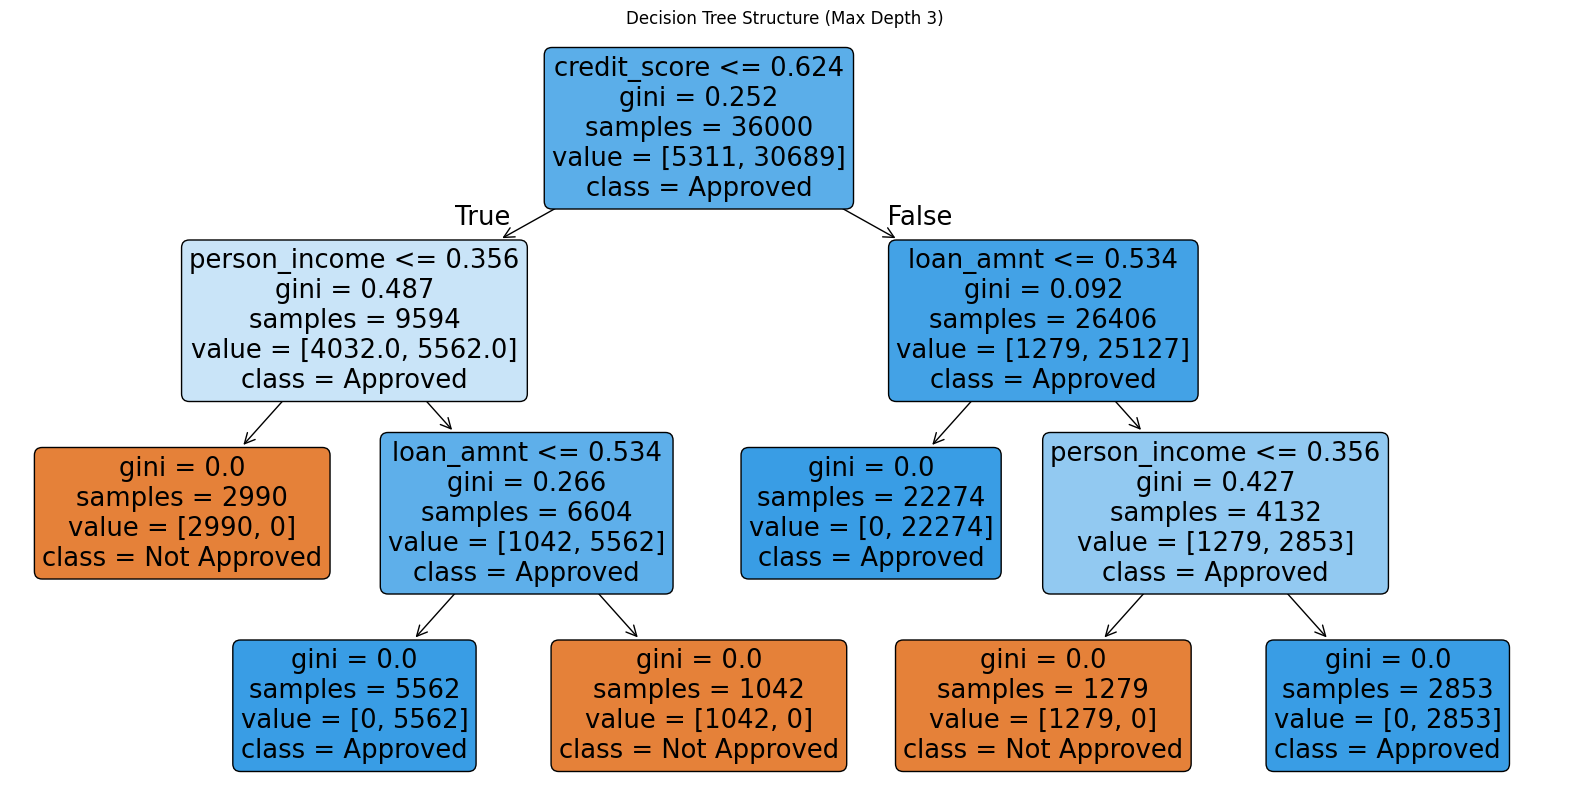

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
# The DecisionTreeClassifier import is only needed if `model` was not defined elsewhere.
# Since `model` is defined and fitted in previous cells, we don't need to re-import it here
# unless we were to re-initialize the model, which was the source of the error.

# --- Understanding the Decision Tree Diagram (for a Layman!) ---

# Think of this diagram as a flowchart a human would use to decide on a loan.
# Each box (called a 'node') represents a step in the decision process.

# Let's break down what's inside each box, especially the top one:
# ------------------------------------------------------------------
# Example box content:
# person_income <= 0.595  <--- THIS IS THE DECISION RULE (THE 'QUESTION')
# gini = 0.25             <--- HOW 'MIXED' THE OUTCOMES ARE HERE
# samples = 36000         <--- NUMBER OF LOAN APPLICATIONS REACHING THIS POINT
# value = [5284, 30716]   <--- COUNT OF 'NOT APPROVED' (0) AND 'APPROVED' (1) LOANS
# class = Approved        <--- THE PREDOMINANT OUTCOME HERE
# ------------------------------------------------------------------

# 1. The Decision Rule (e.g., `person_income <= 0.595`)
#    - This is the question the model asks. For example, 'Is the applicant's income (scaled between 0 and 1) less than or equal to 0.595?'
#    - The `0.595` is a `threshold` (a dividing line) that the model found to be the best place to split the data at this step.
#    - If the answer to the question is 'YES' (True), you follow the path to the LEFT.
#    - If the answer is 'NO' (False), you follow the path to the RIGHT.
#    - The `<=' symbol simply means 'less than or equal to'.

# 2. Gini (e.g., `gini = 0.25`)
#    - Imagine you have a basket of red and green apples. If they are all red or all green, the basket is 'pure'. If it's a mix, it's 'impure'.
#    - Gini is a way for the model to measure how 'mixed' the loan approval decisions are at that particular step in the tree.
#    - A `gini` of 0 means perfect purity (all applications at this point are either 'Approved' or all 'Not Approved').
#    - A `gini` close to 0.5 means a 50/50 mix (very impure).
#    - The model's goal is to choose questions that reduce the `gini` impurity as much as possible at each step, making decisions clearer.

# 3. Samples (e.g., `samples = 36000`)
#    - This tells you how many loan applications are currently being considered at this specific decision point.

# 4. Value (e.g., `value = [5284, 30716]`)
#    - This shows the actual count of loan applications in this box: the first number is 'Not Approved' (Class 0), and the second is 'Approved' (Class 1).

# 5. Class (e.g., `class = Approved`)
#    - This is the most common (or 'majority') outcome among the applications at this point. If you were to stop here, this would be the prediction.

# How to Read the Tree:
# Start at the very top box. Ask the question. Go left if 'Yes', right if 'No'. Keep going until you reach a box with no further branches (a 'leaf node'). That leaf node tells you the final predicted 'class' (Approved or Not Approved) for that particular applicant.

# Removed re-initialization of model and feature_names to ensure the already fitted model is used.
# `model` and `feature_names` are expected to be defined and `model` fitted in previous cells (e.g., `c78acfa4` and `61934163`).

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=feature_names, class_names=['Not Approved', 'Approved'], filled=True, rounded=True)
plt.title("Decision Tree Structure (Max Depth 3)")
plt.show()

This diagram is the visual representation of our Decision Tree model. Each box represents a decision point.

*   **How to read it:** Start at the top. The model asks a question (e.g., `person_income <= 0.45`). If the answer is true, you go left; otherwise, you go right. You follow the path until you reach a final decision box (a 'leaf node') that tells you if the loan is 'Approved' or 'Not Approved'.
*   **Colors**: The colors in the boxes tell you the majority outcome at that stage (e.g., darker blue for 'Approved', lighter for 'Not Approved').
*   **`gini`**: This number shows how 'mixed' the outcomes are at that decision point. The model tries to make this number smaller with each step, creating clearer decisions.

#### What Factors Matter Most?

This chart shows us which input factors (features) were most important for our model's loan approval decisions.

/tmp/ipykernel_3682/148543218.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


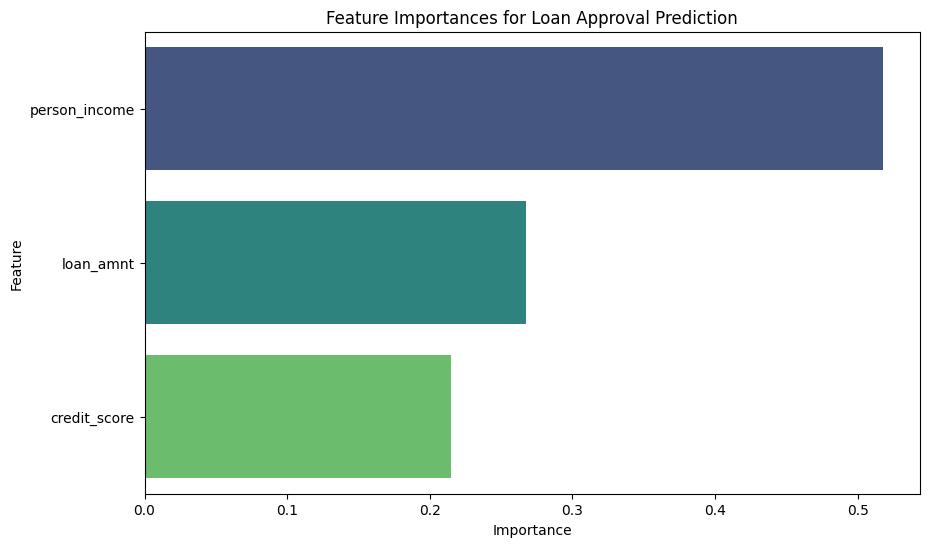

In [ ]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances for Loan Approval Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

This bar chart ranks our input features by their 'importance'.

*   The longer the bar, the more influence that factor had on the model's decisions.
*   *In our case*: `person_income` was the most important factor, followed by `loan_amnt`, and then `credit_score`. This means that, according to our model, a person's income played the biggest role in predicting loan approval.

### 8. Predicting for a New Applicant

Finally, let's see how our trained model would make a decision for a brand new loan application.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

# Create input widgets with reasonable default values and constraints
income_input = widgets.IntText(
    value=70000,
    description='Income ($):',
    disabled=False,
    min=0
)
loan_amnt_input = widgets.IntText(
    value=10000,
    description='Loan Amount ($):',
    disabled=False,
    min=0
)
credit_score_input = widgets.IntText(
    value=720,
    description='Credit Score:',
    disabled=False,
    min=300,
    max=850
)

predict_button = widgets.Button(description="Predict Loan Status")
output_area = widgets.Output()

def on_predict_button_clicked(b):
    with output_area:
        output_area.clear_output() # Clear previous output

        # Get values from widgets
        new_income = income_input.value
        new_loan_amnt = loan_amnt_input.value
        new_credit_score = credit_score_input.value

        # Create numpy array from inputs in the correct order
        new_applicant_data_raw = np.array([[new_income, new_loan_amnt, new_credit_score]])

        # Scale the new applicant data using the *same* scaler fitted on the training data
        # It's crucial to use the scaler that was fitted during data preparation.
        new_applicant_scaled = scaler.transform(new_applicant_data_raw)

        # Make a prediction using the trained model
        prediction = model.predict(new_applicant_scaled)

        # Interpret the prediction for business users
        if prediction[0] == 1:
            result = "<span style='color:green;font-weight:bold;'>Approved</span>"
        else:
            result = "<span style='color:red;font-weight:bold;'>Not Approved</span>"

        # Display the prediction clearly
        display(HTML("<b>Prediction for a new applicant:</b>"))
        display(HTML(f"Income: ${new_income:,.0f}"))
        display(HTML(f"Loan Amount: ${new_loan_amnt:,.0f}"))
        display(HTML(f"Credit Score: {new_credit_score}"))
        display(HTML(f"<b>Loan Status: {result}</b>"))

predict_button.on_click(on_predict_button_clicked)

# Display widgets in the notebook
display(income_input, loan_amnt_input, credit_score_input, predict_button, output_area)


IntText(value=70000, description='Income ($):')

IntText(value=10000, description='Loan Amount ($):')

IntText(value=720, description='Credit Score:')

Button(description='Predict Loan Status', style=ButtonStyle())

Output()

Here, we simulate a new loan applicant with a specific income, loan amount, and credit score. We then ask our trained model to predict their loan status.

*   **Key Step**: We make sure to scale the new applicant's data *exactly* the same way we scaled our training data, so the model can understand it correctly.
*   The model then makes its prediction, and we translate that into a clear 'Approved' or 'Not Approved' message.

This demonstrates the practical use of our model: taking new information and instantly providing an informed decision.